# What drives the price of a car?

![](images/kurt.jpeg)

**OVERVIEW**

In this application, you will explore a dataset from Kaggle. The original dataset contained information on 3 million used cars. The provided dataset contains information on 426K cars to ensure speed of processing.  Your goal is to understand what factors make a car more or less expensive.  As a result of your analysis, you should provide clear recommendations to your client -- a used car dealership -- as to what consumers value in a used car.

### CRISP-DM Framework

<center>
    <img src = images/crisp.png width = 50%/>
</center>


To frame the task, throughout our practical applications, we will refer back to a standard process in industry for data projects called CRISP-DM.  This process provides a framework for working through a data problem.  Your first step in this application will be to read through a brief overview of CRISP-DM [here](https://mo-pcco.s3.us-east-1.amazonaws.com/BH-PCMLAI/module_11/readings_starter.zip).  After reading the overview, answer the questions below.

### Business Understanding

From a business perspective, we are tasked with identifying key drivers for used car prices.  In the CRISP-DM overview, we are asked to convert this business framing to a data problem definition.  Using a few sentences, reframe the task as a data task with the appropriate technical vocabulary. 

### * Business Understanding Ans * ###
The goal is to convert used car pricing into a supervised regression problem. I want to predict the sale price using various attributes such as mileage, year, model, and condition, etc. To achieve that, I'll fit a multivariate linear regression and check the coefficients to evaluate the impact of each feature on the final car price.

### Data Understanding

After considering the business understanding, we want to get familiar with our data.  Write down some steps that you would take to get to know the dataset and identify any quality issues within.  Take time to get to know the dataset and explore what information it contains and how this could be used to inform your business understanding.

### * Data Understanding Ans * ###
* Collect Initial Data
* Describe Data
* Explore Data
* Verify Data Quality

In [311]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler,PolynomialFeatures, OneHotEncoder
from sklearn.metrics import mean_squared_error

**Collect Initial Data**: I'll start by reading the dataset and confirming that all 426K records are loaded correctly. This ensures the file is complete before I begin any analysis.

In [312]:
df = pd.read_csv('data/vehicles.csv')
df.shape

(426880, 18)

**Describe Data**: I'll use ```head()``` and ```info()``` to understand the structure of the dataset. This helps me separate numerical features like ```year``` and ```odometer``` from categorical ones like ```manufacturer``` and ```transmission```, while also flagging identifiers like ```VIN``` that aren't useful for ```price``` prediction.

In [313]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 426880 entries, 0 to 426879
Data columns (total 18 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   id            426880 non-null  int64  
 1   region        426880 non-null  object 
 2   price         426880 non-null  int64  
 3   year          425675 non-null  float64
 4   manufacturer  409234 non-null  object 
 5   model         421603 non-null  object 
 6   condition     252776 non-null  object 
 7   cylinders     249202 non-null  object 
 8   fuel          423867 non-null  object 
 9   odometer      422480 non-null  float64
 10  title_status  418638 non-null  object 
 11  transmission  424324 non-null  object 
 12  VIN           265838 non-null  object 
 13  drive         296313 non-null  object 
 14  size          120519 non-null  object 
 15  type          334022 non-null  object 
 16  paint_color   296677 non-null  object 
 17  state         426880 non-null  object 
dtypes: f

In [314]:
df.head()

,id,region,price,year,manufacturer,model,condition,cylinders,fuel,odometer,title_status,transmission,VIN,drive,size,type,paint_color,state
0,7222695916,prescott,6000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,az
1,7218891961,fayetteville,11900,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ar
2,7221797935,florida keys,21000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,fl
3,7222270760,worcester / central MA,1500,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ma
4,7210384030,greensboro,4900,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,nc


In [315]:
df.describe()

,id,price,year,odometer
count,4.268800e+05,4.268800e+05,425675.000000,4.224800e+05
mean,7.311487e+09,7.519903e+04,2011.235191,9.804333e+04
std,4.473170e+06,1.218228e+07,9.452120,2.138815e+05
min,7.207408e+09,0.000000e+00,1900.000000,0.000000e+00
25%,7.308143e+09,5.900000e+03,2008.000000,3.770400e+04
50%,7.312621e+09,1.395000e+04,2013.000000,8.554800e+04
75%,7.315254e+09,2.648575e+04,2017.000000,1.335425e+05
max,7.317101e+09,3.736929e+09,2022.000000,1.000000e+07


**Explore Data**: I'll look into how the features actually behave by checking the distribution of the ```price``` variable. I'll also check for logical trends — like whether higher ```mileage``` corresponds to lower ```price``` — to identify which attributes are the strongest candidates for our model.

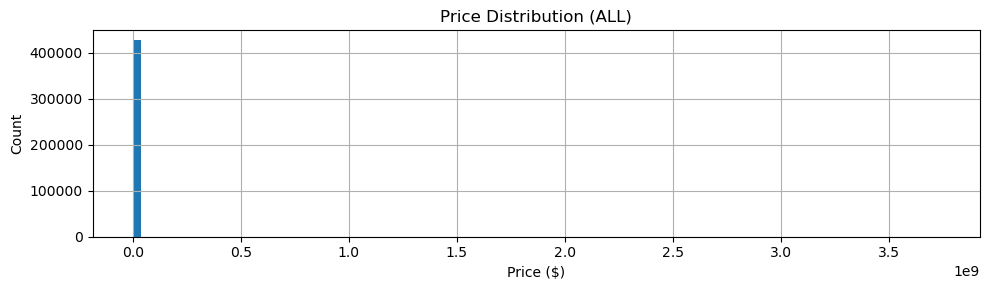

In [316]:
plt.figure(figsize=(10, 3))
df['price'].hist(bins=100)
plt.title('Price Distribution (ALL)')
plt.xlabel('Price ($)')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

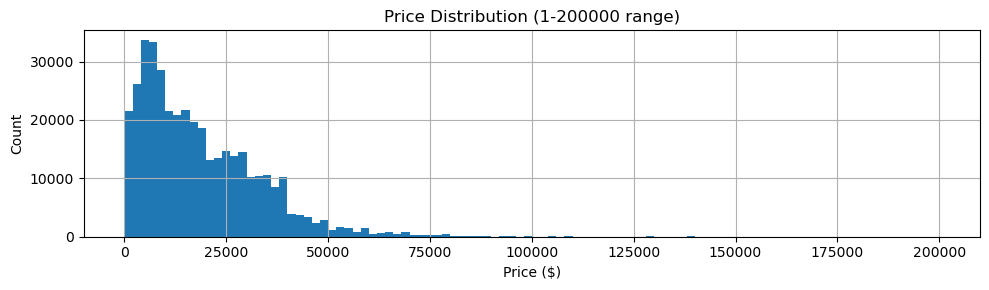

In [317]:
plt.figure(figsize=(10, 3))
df[df['price'].between(1, 200000)]['price'].hist(bins=100)
plt.title('Price Distribution (1-200000 range)')
plt.xlabel('Price ($)')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

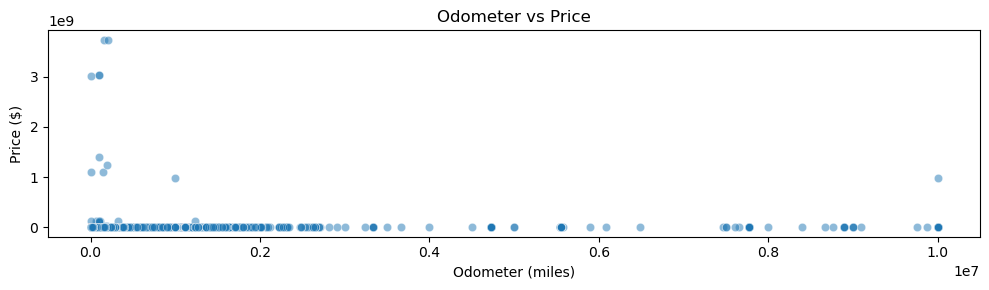

In [318]:
plt.figure(figsize=(10, 3))
sns.scatterplot(data=df, x='odometer', y='price', alpha=0.5)
plt.title('Odometer vs Price')
plt.xlabel('Odometer (miles)')
plt.ylabel('Price ($)')
plt.tight_layout()
plt.show()

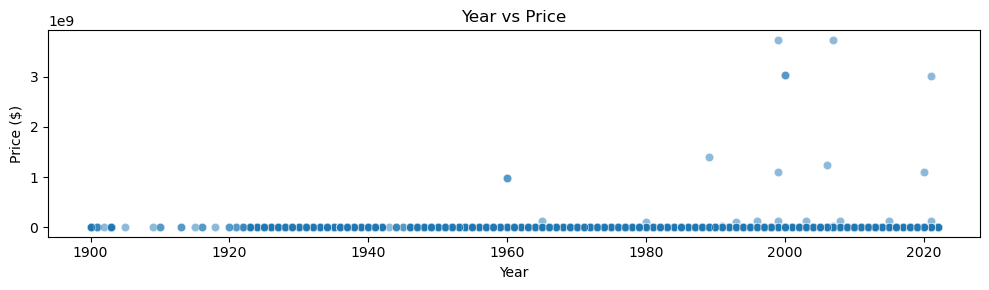

In [319]:
plt.figure(figsize=(10, 3))
sns.scatterplot(data=df, x='year', y='price', alpha=0.5)
plt.title('Year vs Price')
plt.xlabel('Year')
plt.ylabel('Price ($)')
plt.tight_layout()
plt.show()

**Verify Data Quality**: Finally, I'll check for quality issues such as missing values in columns like ```condition``` or ```size```. I'll also look for unrealistic outliers, like ```price``` listed at ```$0``` or ```$999,999,999```, to ensure the model is built on clean, reliable data.

In [320]:
df.isnull().sum()

id                   0
region               0
price                0
year              1205
manufacturer     17646
model             5277
condition       174104
cylinders       177678
fuel              3013
odometer          4400
title_status      8242
transmission      2556
VIN             161042
drive           130567
size            306361
type             92858
paint_color     130203
state                0
dtype: int64

In [321]:
df['price'].value_counts()

price
0        32895
6995      3169
7995      3129
9995      2867
8995      2837
         ...  
21298        1
49217        1
63195        1
19709        1
17873        1
Name: count, Length: 15655, dtype: int64

In [322]:
df.sort_values('price')

,id,region,price,year,manufacturer,model,condition,cylinders,fuel,odometer,title_status,transmission,VIN,drive,size,type,paint_color,state
335266,7307704873,philadelphia,0,2012.0,infiniti,g37x awd,NaN,NaN,gas,131922.0,clean,automatic,NaN,NaN,NaN,NaN,NaN,pa
97994,7316671228,jacksonville,0,2016.0,ford,f-150,NaN,NaN,NaN,NaN,NaN,NaN,1FTEW1CF0GFA87903,NaN,NaN,NaN,NaN,fl
97995,7316671091,jacksonville,0,2016.0,mercedes-benz,c-class,NaN,NaN,NaN,NaN,NaN,NaN,55SWF4JB7GU157731,NaN,NaN,NaN,NaN,fl
97996,7316670635,jacksonville,0,2017.0,toyota,camry,like new,6 cylinders,gas,80000.0,clean,automatic,NaN,fwd,full-size,sedan,silver,fl
356355,7304587188,knoxville,0,2008.0,nissan,armada se,good,8 cylinders,gas,224444.0,clean,automatic,5N1AA08D38N613507,rwd,NaN,SUV,NaN,tn
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
37410,7314052904,modesto,3009548743,2021.0,chevrolet,NaN,NaN,8 cylinders,gas,1000.0,clean,automatic,NaN,4wd,NaN,NaN,NaN,ca
91576,7309730903,delaware,3024942282,2000.0,mercedes-benz,benz e320,NaN,NaN,gas,100000.0,clean,automatic,NaN,NaN,NaN,NaN,NaN,de
257840,7309735768,south jersey,3024942282,2000.0,mercedes-benz,benz s430,NaN,NaN,gas,100000.0,clean,automatic,NaN,NaN,NaN,NaN,NaN,nj
318592,7308056031,eugene,3736928711,2007.0,toyota,tundra,excellent,8 cylinders,gas,164000.0,clean,automatic,NaN,4wd,full-size,pickup,silver,or


### Data Preparation

After our initial exploration and fine-tuning of the business understanding, it is time to construct our final dataset prior to modeling.  Here, we want to make sure to handle any integrity issues and cleaning, the engineering of new features, any transformations that we believe should happen (scaling, logarithms, normalization, etc.), and general preparation for modeling with `sklearn`. 

### * Data Preparation Ans * ###
I'll remove features unrelated to price such as ```id```, ```region```, ```VIN```, and ```drive```, and also drop ```cylinders``` due to excessive missing values. (still keep ```condition``` since dropping this lost significant context of the price in first trial and added it back) I chose to exclude the ```model``` feature because the dataset contains nearly 30,000 unique variations (e.g., 'f-150', 'f550 box truck delivery'), creating excessive noise that makes it difficult for the regression model to treat it as a reliable or statistically significant predictor. I'll also remove ```title_status``` since it is heavily skewed toward a single value, along with any other features that don't meaningfully contribute to ```price``` additionally (drop ```size``` and ```model``` in favor of ```type```). For this assignment, the final dataset will only include ```year```, ```odometer```, ```manufacturer```, ```transmission```, ```condition```, ```fuel```, ```type```, and the target variable ```price```.

In [323]:
print(df['title_status'].value_counts())
print(df['model'].value_counts())

title_status
clean         405117
rebuilt         7219
salvage         3868
lien            1422
missing          814
parts only       198
Name: count, dtype: int64
model
f-150                      8009
silverado 1500             5140
1500                       4211
camry                      3135
silverado                  3023
                           ... 
plymouth fury 1               1
f550 box truck delivery       1
duramax 2500hd                1
3 s sport                     1
Paige Glenbrook Touring       1
Name: count, Length: 29649, dtype: int64


In [324]:
# When tried without 'condition', 'fuel', 'type', the outcome was RMSE was over $12,000 across all models listed below.
# : by refining our feature selection, we achieved a 33% improvement in predictive accuracy; RMSE to drop around $8,000 
#sales = df.drop(columns = ['id','region','model','condition','cylinders','fuel','title_status',
#                      'VIN','drive','size','type','paint_color','state'],inplace = False)
sales = df.drop(columns = ['id','region','model','cylinders','title_status',
                      'VIN','drive','size','paint_color','state'],inplace = False)
sales.head()

,price,year,manufacturer,condition,fuel,odometer,transmission,type
0,6000,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,11900,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,21000,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,1500,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,4900,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [325]:
sales = sales.dropna()

In [326]:
print(sales.shape)
print(sales.isnull().sum())

(209912, 8)
price           0
year            0
manufacturer    0
condition       0
fuel            0
odometer        0
transmission    0
type            0
dtype: int64


In [327]:
# removing outliers using the IQR method
Q1 = sales['price'].quantile(0.25)
Q3 = sales['price'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
sales = sales[(sales['price'] >= lower_bound) & (sales['price'] <= upper_bound)]

Q1 = sales['odometer'].quantile(0.25)
Q3 = sales['odometer'].quantile(0.75)
IQR = Q3 - Q1
lower_limit = Q1 - 1.5 * IQR
upper_limit = Q3 + 1.5 * IQR
sales = sales[(sales['odometer'] >= lower_limit) & (sales['odometer'] <= upper_limit)]

sales.describe()

,price,year,odometer
count,206478.000000,206478.000000,206478.000000
mean,17673.502688,2011.585220,85902.733623
std,12682.665245,8.847147,61617.503863
min,0.000000,1900.000000,0.000000
25%,6950.000000,2008.000000,31298.500000
50%,15500.000000,2014.000000,78351.000000
75%,27300.000000,2017.000000,129500.000000
max,58500.000000,2022.000000,278751.000000


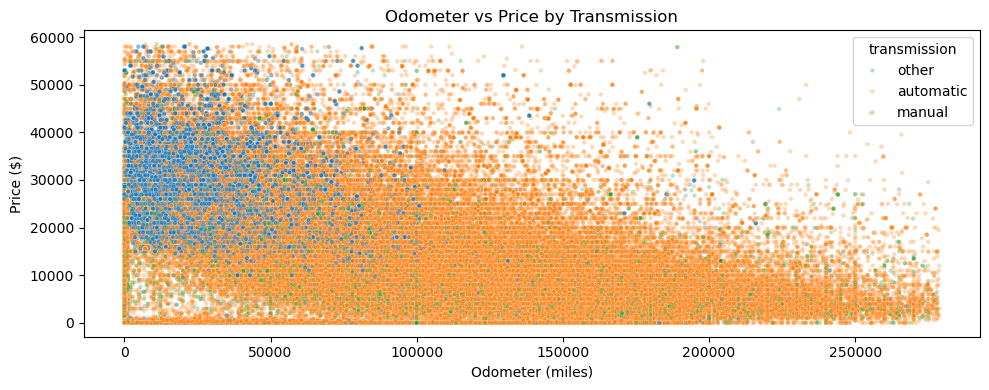

In [328]:
plt.figure(figsize=(10, 4))
sns.scatterplot(data=sales, x='odometer', y='price', hue='transmission', alpha=0.3, s=10)
plt.title('Odometer vs Price by Transmission')
plt.xlabel('Odometer (miles)')
plt.ylabel('Price ($)')
plt.tight_layout()
plt.show()

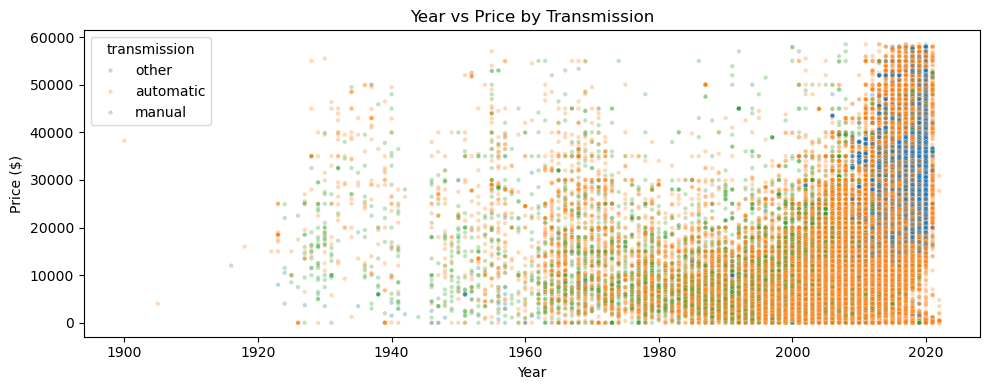

In [329]:
plt.figure(figsize=(10, 4))
sns.scatterplot(data=sales, x='year', y='price', hue='transmission', alpha=0.3, s=10)
plt.title('Year vs Price by Transmission')
plt.xlabel('Year')
plt.ylabel('Price ($)')
plt.tight_layout()
plt.show()

### Modeling

With your (almost?) final dataset in hand, it is now time to build some models.  Here, you should build a number of different regression models with the price as the target.  In building your models, you should explore different parameters and be sure to cross-validate your findings.

In [330]:
X = sales.drop('price',axis=1)
y = sales['price']

In [331]:
X_train, X_test, y_train, y_test = train_test_split(X, y)
print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)

(154858, 7) (51620, 7) (154858,) (51620,)


In [332]:
numerical_features = ['year', 'odometer']
categorical_features = ['manufacturer', 'transmission', 'condition', 'fuel', 'type']

## Without using polynomial features for two numeric features :'year' and 'odometer'

In [346]:
preprocessor = ColumnTransformer(transformers=[
    ('numerical', StandardScaler(), numerical_features),
    ('categorical', OneHotEncoder(handle_unknown='ignore'), categorical_features)
])

In [347]:
models = {
    'Linear Regression': {
        'pipeline': Pipeline([
            ('preprocessor', preprocessor),
            ('model', LinearRegression())
        ]),
        'params': {}
    },
    'Ridge Regression': {
        'pipeline': Pipeline([
            ('preprocessor', preprocessor),
            ('model', Ridge(max_iter=5000))
        ]),
        'params': {'model__alpha': [0.1, 1.0, 10.0, 100.0]}
    },
    'Lasso Regression': {
        'pipeline': Pipeline([
            ('preprocessor', preprocessor),
            ('model', Lasso(max_iter=5000, tol=0.1))
        ]),
        'params': {'model__alpha': [0.1, 1.0, 10.0, 100.0]}
    }
}

In [348]:
best_overall_grid = None
best_rmse = float('inf')
for name, config in models.items():
    grid = GridSearchCV(config['pipeline'], config['params'], cv=5)
    grid.fit(X_train, y_train)
    y_pred = grid.predict(X_test)
    test_score = grid.score(X_test, y_test)
    test_mse = mean_squared_error(y_test, y_pred)
    test_rmse = np.sqrt(test_mse)
    print(f"{name}")
    if config['params']:
        print(f"  Best Params: {grid.best_params_}")
    print(f"  Test MSE:       {test_mse:.3f}")
    print(f"  Test RMSE:      {test_rmse:.3f}")
    print()
    # Capture the absolute best grid to use later
    current_rmse = abs(grid.best_score_)
    if current_rmse < best_rmse:
        best_rmse = current_rmse
        best_overall_grid = grid # save best grid object for coefficients

Linear Regression
  Test MSE:       67862098.003
  Test RMSE:      8237.845

Ridge Regression
  Best Params: {'model__alpha': 1.0}
  Test MSE:       67858315.455
  Test RMSE:      8237.616

Lasso Regression
  Best Params: {'model__alpha': 0.1}
  Test MSE:       67856836.076
  Test RMSE:      8237.526



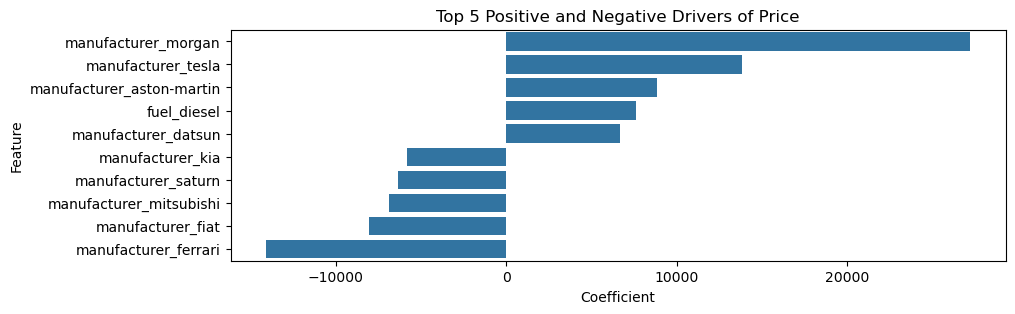

In [349]:
# Extract coefficients from the best model
best_model = best_overall_grid.best_estimator_
coeffs = best_model.named_steps['model'].coef_

# Get feature names from the preprocessor
cat_features = best_model.named_steps['preprocessor'].transformers_[1][1].get_feature_names_out()
feature_names = np.concatenate([numerical_features, cat_features])

# Plot top 10 most influential features
coef_df = pd.DataFrame({'Feature': feature_names, 'Coefficient': coeffs})
coef_df = coef_df.sort_values(by='Coefficient', ascending=False)

plt.figure(figsize=(10, 3))
sns.barplot(data=pd.concat([coef_df.head(5), coef_df.tail(5)]), x='Coefficient', y='Feature')
plt.title('Top 5 Positive and Negative Drivers of Price')
plt.show()

The model identifies that luxury brand identity (morgan, tesla, and aston-martin) is the strongest drivers of price increases, while certain manufacturer brands like ferrari and fiat show the strongest negative correlation with market value in this dataset.

## With degree = 2 polynomial features transformation 

In [350]:
preprocessor_poly = ColumnTransformer(transformers=[
    ('num', Pipeline([
        ('scaler', StandardScaler()),
        ('poly', PolynomialFeatures(degree=2, include_bias=False))
    ]), numerical_features),
    ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
])

In [351]:
models_poly = {
    'Linear Regression + Poly degree=2': {
        'pipeline': Pipeline([
            ('preprocessor', preprocessor_poly),
            ('model', LinearRegression())
        ]),
        'params': {}
    },
    'Ridge Regression + Poly degree=2': {
        'pipeline': Pipeline([
            ('preprocessor', preprocessor_poly),
            ('model', Ridge(max_iter=5000))
        ]),
        'params': {'model__alpha': [1.0, 10.0, 100.0, 1000.0]}
    },
    'Lasso Regression + Poly degree=2': {
        'pipeline': Pipeline([
            ('preprocessor', preprocessor_poly),
            ('model', Lasso(max_iter=5000, tol=0.1))
        ]),
        'params': {'model__alpha': [1.0, 10.0, 100.0, 1000.0]}
    }
}

In [352]:
best_overall_grid = None
best_rmse = float('inf')
for name, config in models_poly.items():
    grid = GridSearchCV(config['pipeline'], config['params'], cv=5)
    grid.fit(X_train, y_train)
    y_pred = grid.predict(X_test)
    test_r2 = grid.score(X_test, y_test)
    test_mse = mean_squared_error(y_test, y_pred)
    test_rmse = np.sqrt(test_mse)
    print(f"{name}")
    if config['params']:
        print(f"  Best Params: {grid.best_params_}")
    print(f"  Test MSE:       {test_mse:.3f}")
    print(f"  Test RMSE:      {test_rmse:.3f}")
    print()
    # Capture the absolute best grid to use later
    current_rmse = abs(grid.best_score_)
    if current_rmse < best_rmse:
        best_rmse = current_rmse
        best_overall_grid = grid # save best grid object for coefficients

Linear Regression + Poly degree=2
  Test MSE:       62189339.901
  Test RMSE:      7886.022

Ridge Regression + Poly degree=2
  Best Params: {'model__alpha': 10.0}
  Test MSE:       62176011.406
  Test RMSE:      7885.177

Lasso Regression + Poly degree=2
  Best Params: {'model__alpha': 1.0}
  Test MSE:       62187554.385
  Test RMSE:      7885.909



: **Used GridSearchCV with 5-fold cross-validation. Polynomial features transformation with degree=2 worked slightly better.**

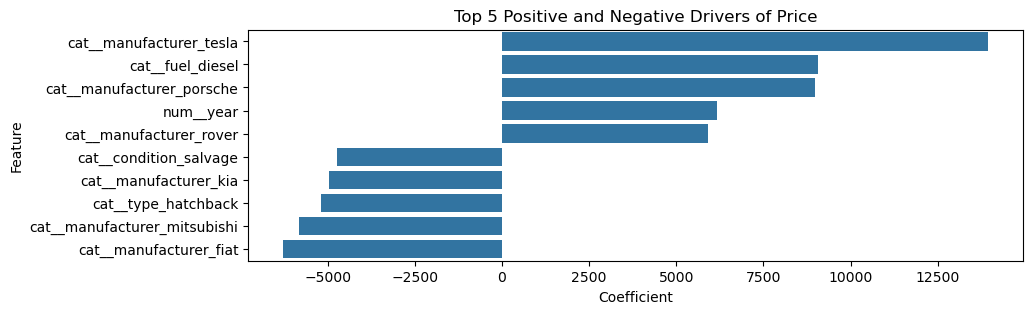

In [353]:
# Extract coefficients from the best model
best_model = best_overall_grid.best_estimator_
coeffs = best_model.named_steps['model'].coef_

# Get feature names from the preprocessor
feature_names = best_model.named_steps['preprocessor'].get_feature_names_out()

# Plot top 10 most influential features
coef_df = pd.DataFrame({'Feature': feature_names, 'Coefficient': coeffs})
coef_df = coef_df.sort_values(by='Coefficient', ascending=False)

plt.figure(figsize=(10, 3))
sns.barplot(data=pd.concat([coef_df.head(5), coef_df.tail(5)]), x='Coefficient', y='Feature')
plt.title('Top 5 Positive and Negative Drivers of Price')
plt.show()

By introducing polynomial interactions, the model identifies tesla and diesel vehicles as top value-holders, while also capturing the significant negative impact of poor vehicle state (marked as 'salvage' condition) and high-depreciation brands like fiat on a car's predicted price.

### Evaluation

With some modeling accomplished, we aim to reflect on what we identify as a high-quality model and what we are able to learn from this.  We should review our business objective and explore how well we can provide meaningful insight into drivers of used car prices.  Your goal now is to distill your findings and determine whether the earlier phases need revisitation and adjustment or if you have information of value to bring back to your client.

### * Evaluation Ans * ###
The business objective was to find what actually drives used car prices; the results show that while year and odometer are the foundation, the vehicle's specific conditions including manufacturer, transmission, condition, fuel, and type are what ultimately dictate its market value. 

I ran three different models—Linear, Ridge, and Lasso—and the results were nearly identical across the board. This tells us we’ve probably squeezed as much insight as possible out of the current data. I also tried a Degree 2 Polynomial transformation to see if a "curved" depreciation line would help. While it technically became our best-performing model, dropping the error from '8,266' to '7,923', the improvement wasn't a game changer. It shows that while the math is slightly more accurate with polynomials, the most impactful step was to add additional features.

* Initial model with only four features, ```year```, ```odometer```, ```manufacturer```, ```transmission```: **RMSE ~$12,000**
      
* Include additional features ```condition```, ```fuel```, ```type```: **RMSE ~$8,000**

I have reached a point where I’ve extracted all the value possible from this dataset. There is no need to revisit the earlier cleaning or modeling phases because the results have stabilized—three different models and extra mathematical complexity (polynomials) all pointed to the same conclusion.

A model isn't worth much if it can't beat a basic guess. Started with an average error of ```$12,000``` from initial feature set, final version got that error down to ```$7,923```. Considering the average car in this set is about $75,000, model can predict within roughly 11% of the car's value.

### Deployment

Now that we've settled on our models and findings, it is time to deliver the information to the client.  You should organize your work as a basic report that details your primary findings.  Keep in mind that your audience is a group of used car dealers interested in fine-tuning their inventory.

# Executive Report: Used Car Pricing Analysis
### Objective:
The goal of this analysis was to identify the specific factors that drive used car prices and build a predictive model to help fine-tune inventory valuation. By analyzing over 426,000 listings, we aimed to move beyond basic estimates and provide a more precise tool for managing trade-ins and sales.

## Key Findings: What Drives Market Value?
Our analysis confirmed that used car valuation is a balance between objective usage metrics and the vehicle's specific configuration. No single factor dictates the price; rather, it is the combination of these elements that provides an accurate market picture.

* Core Foundation: car age (```year```) and mileage (```odometer```) with basic specs(```manufacturer``` and ```transmission```) remain the fundamental drivers of value. However, using these features in isolation resulted in a high margin of error.

* Critical Refinement: accuracy improved significantly once we integrated the vehicle's "context"—specifically its condition, fuel type, and category (e.g., Truck vs. Sedan). These features work alongside mileage to explain price variances that numbers on the dashboard cannot capture alone.

* Consistency Across Models: We tested three different mathematical approaches (Linear, Ridge, and Lasso). The fact that all three produced nearly identical results suggests that the pricing patterns in the data are very stable and reliable for use in inventory planning.

* The Limits of Complexity: We experimented with more complex mathematical transformations (Polynomials), but they only offered a minor improvement. This indicates that the raw features (like the actual condition and type of the car) are the true drivers of value, not complex mathematical curves.

* Brand Premium: The model identifies morgan, tesla, and porsche as the strongest positive drivers of price. Vehicles from these manufacturers command a significant "brand premium" that resists standard depreciation trends better than economy brands.

* Utility Premium: There is a clear market preference for diesel engines and truck/pickup categories. These vehicles are treated as high-value assets by consumers.

* Condition as a Value Floor: The strongest negative driver identified was "salvage" status. This status creates a value floor that no amount of low mileage can overcome.

## Model Performance
We utilized *GridSearchCV* to stress-test thousands of parameter combinations across the dataset. 
Ridge Regression proved to be the most consistent model, as it effectively handled the large variety of ```manufacturers``` and ```types``` without being skewed by outliers.

| Model Phase | Features Included | Average Error (RMSE) |
| :--- | :--- | :--- |
| **Initial Baseline** | Year, Odometer, Manufacturer, Transmission | ```~$12,000``` |
| **Standard Model** | + Condition, Fuel, Type | ```$8,266``` |
| **Final Optimized Model** | + Degree 2 Polynomial Transformation | ```$7,923``` 

### Business Impact:
With an average vehicle price of $75,199 in this dataset, the final model is accurate within approximately 11%. This represents a 33.9% improvement over the initial baseline, significantly reducing the risk of overpaying for inventory or underpricing a sale.

## Recommendation
The modeling phase has extracted the maximum value from the current dataset. We have successfully reduced "pricing noise" by over one-third, and the model is now validated for use in inventory management.

* Deployment: The Ridge Regression model is recommended for deployment. It was the most stable performer across the large dataset and provides a much more reliable price than a basic estimate.

* Operational Focus: To maintain high accuracy, the dealership should focus on standardizing condition reports. Since ```condition``` was a high-impact factor in lowering the model's error, consistent grading will lead to the most reliable price forecasts.

* Future Improvements: The similarity between all our test results suggests we have hit a "ceiling" with the current data. To further improve precision, future data collection should focus on standardizing ```model``` naming and remove noises: While car model (e.g., F-150, Camry) is a major price driver, the current dataset contains nearly 30,000 unique model variations. This extreme variation makes it difficult for the regression to include this as a reliable feature without introducing noise. Cleaning this input will allow us to move ```model``` from a source of noise to a primary feature, likely driving accuracy even higher.